# Analysis of transaction features before the attack

In [10]:
from parameters import Parameters, CardSimParameters, PPOParameters, ClassificationParameters, EnvParameters


params = Parameters(
    cardsim=CardSimParameters.paper_params(with_modification=False, ulb_data=False),
    agent=PPOParameters(),
    clf_params=ClassificationParameters(use_anomaly=False),
    env_params=EnvParameters(terminal_fract=0.2)
)

## Gather features without attack

In [8]:
from datetime import timedelta
import polars as pl
from tqdm import tqdm

banksys = params.load_banksys()
features_over_time_without_attack = list[dict]()
for day in tqdm(range(60)):
    features = banksys._fast_forward(banksys.current_time + timedelta(days=1), compute_features=True, show_progress=False)
    features = pl.DataFrame(features, schema=banksys.schema)
    features_over_time_without_attack.append(features.mean().to_dict())

100%|██████████| 60/60 [01:02<00:00,  1.04s/it]


## Gather features during the attack

In [3]:
from runner import Runner

runner = Runner(params)
episodes = runner.run()

2023-03-02 avg score=0.00 - len-avg=0.00 - total=0.00:   0%|          | 0/4000 [00:00<?, ?episode/s]WARNING:root:TensorBoard writer is not initialized.
2023-05-14 avg score=522.17 - len-avg=9.42 - total=1354533.02: 100%|██████████| 4000/4000 [06:19<00:00, 10.53episode/s, trx=37349]


In [4]:
env = runner.env
fot_other = list[pl.DataFrame]()
fot_frauds = list[dict]()

for dt, fraud in env.fraud_features.items():
    d = dt.date()
    fraud["date"] = d
    fot_frauds.append(fraud)
fot_frauds_df = pl.DataFrame(fot_frauds)
fraud_features = fot_frauds_df.group_by("date").mean().sort("date").to_dicts()

for dt, other in env.other_features.items():
    d = dt.date()
    fot_other.append(other.with_columns(date=pl.lit(d)))
fot_other_df = pl.concat(fot_other)
other_features = fot_other_df.group_by("date").mean().sort("date").to_dicts()

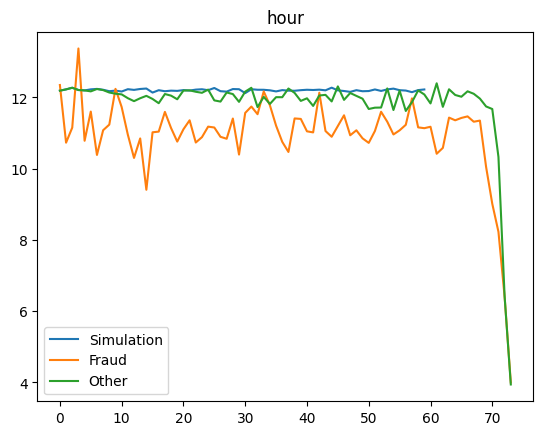

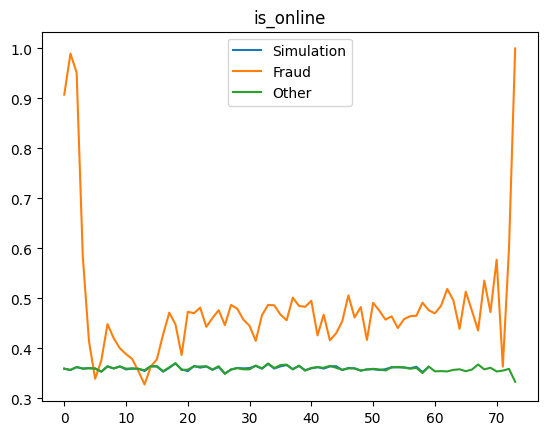

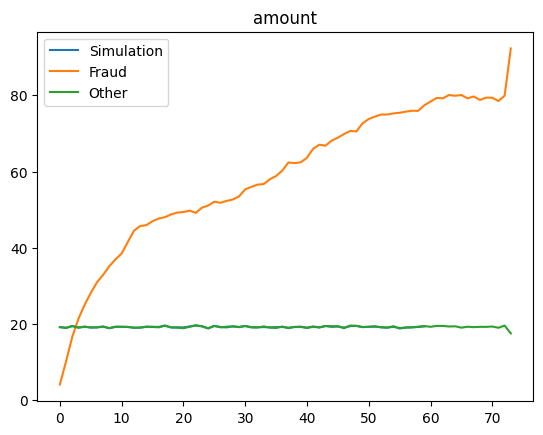

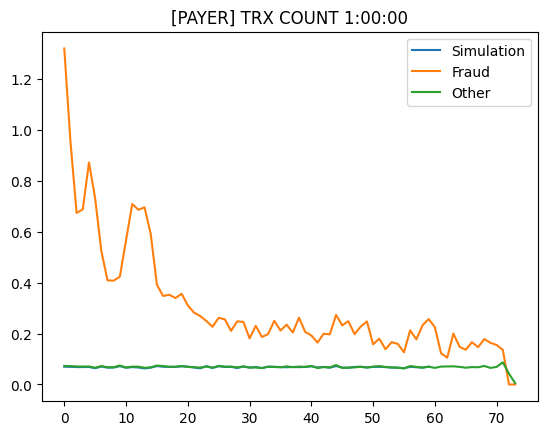

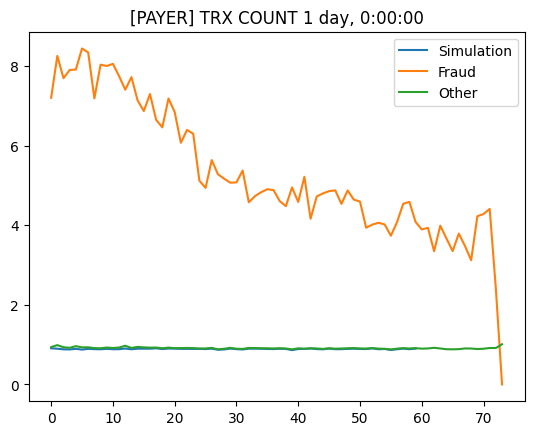

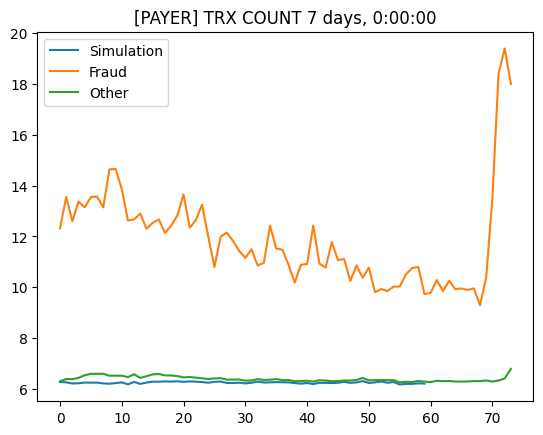

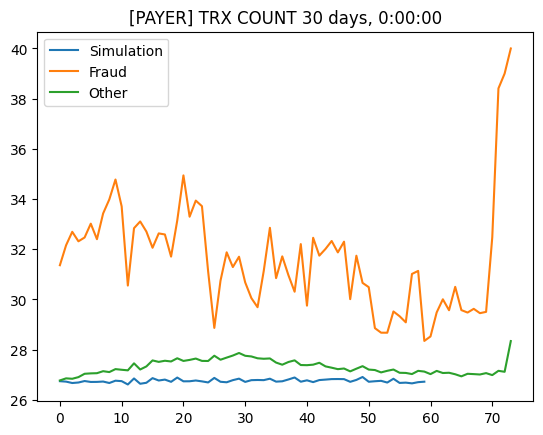

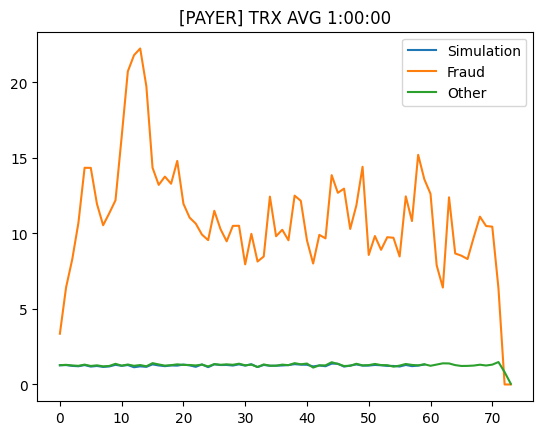

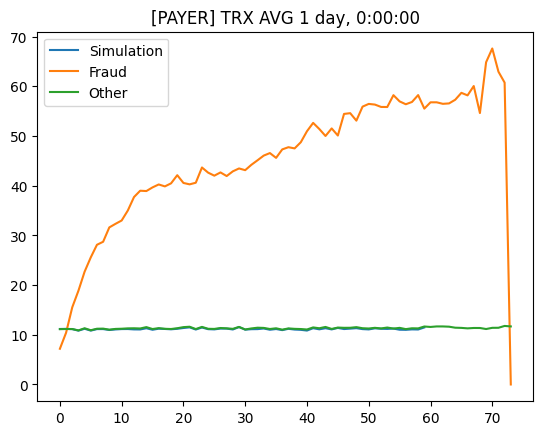

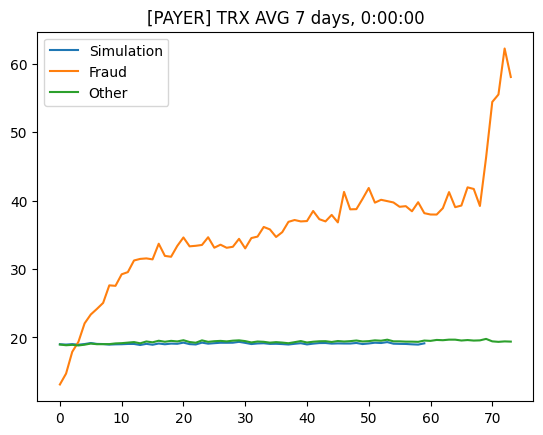

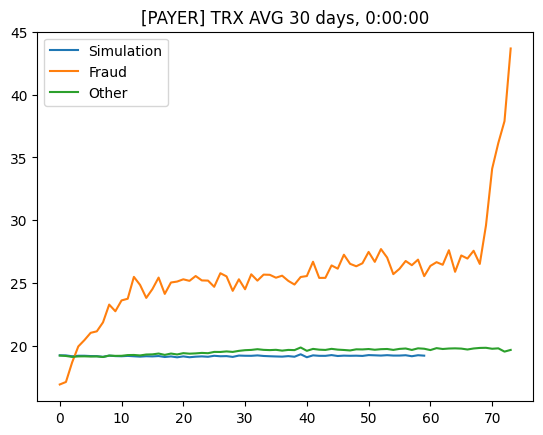

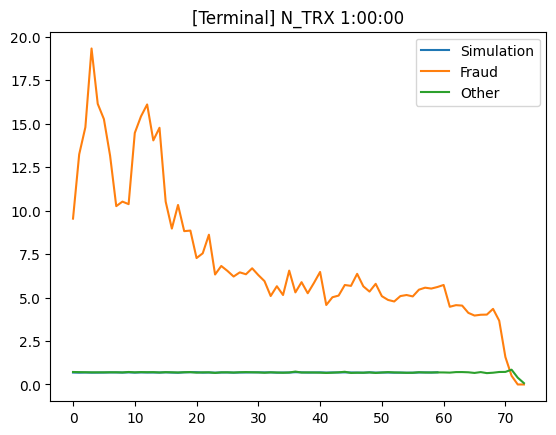

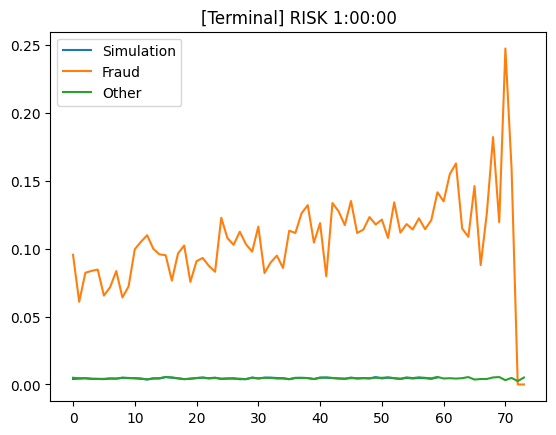

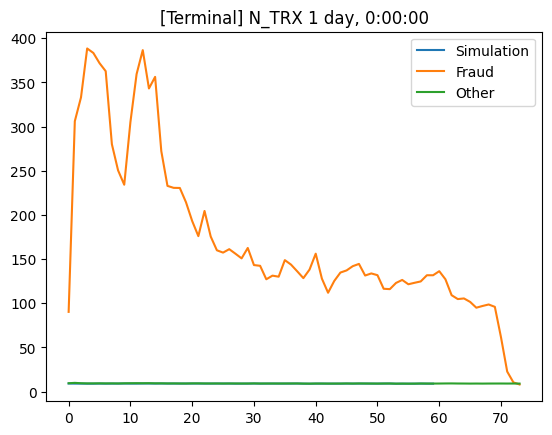

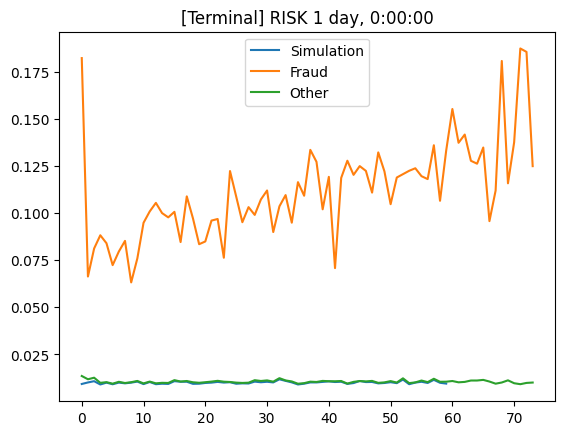

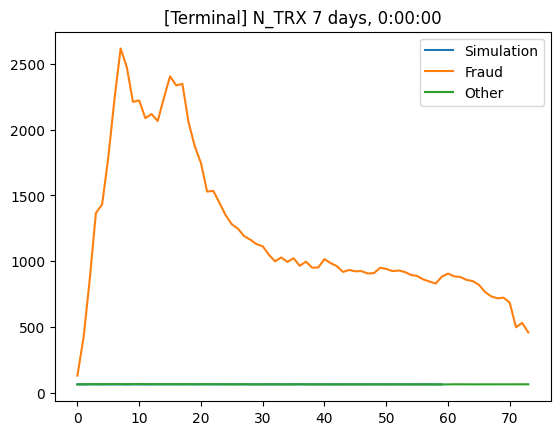

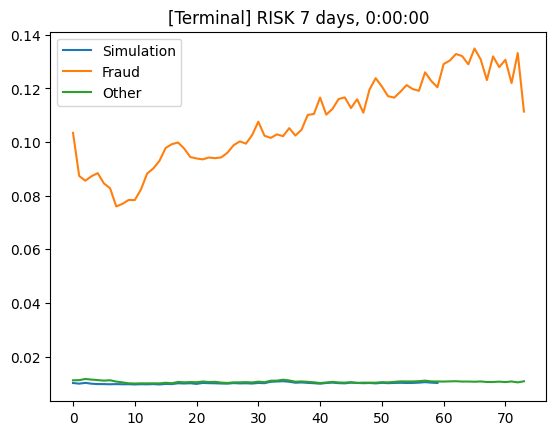

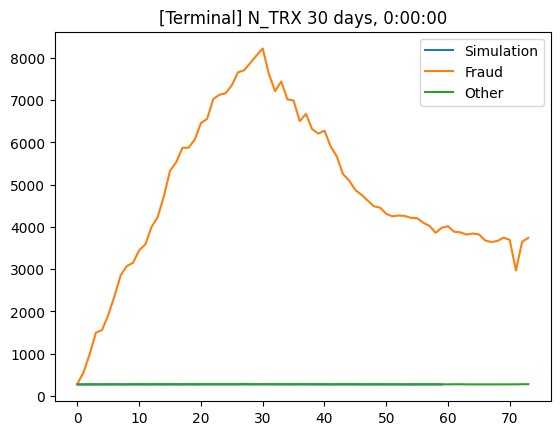

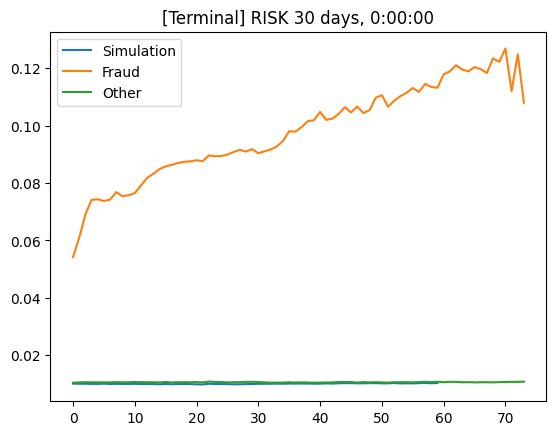

In [9]:
import matplotlib.pyplot as plt

keys = features_over_time_without_attack[0].keys()

for key in keys:
    if key in ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]:
        continue
    plt.title(key)
    plt.plot([f[key] for f in features_over_time_without_attack], label="Simulation")
    plt.plot([f[key] for f in fraud_features], label="Fraud")
    plt.plot([f[key] for f in other_features], label="Other")
    plt.legend()
    plt.show()